<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/ML_Mid_Term.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
print('Name: Al Fattaul Islam')
print('Email: alfattaulislamss@gmail.com')

Name: Al Fattaul Islam
Email: alfattaulislamss@gmail.com


In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_error,  mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Dataset Reference: https://drive.google.com/file/d/1cCB19GQ3Of92RAk5TVb0DPohCt1eZR6d/view?usp=sharing

# Question 1: Exploratory Data Analysis (EDA) -20
Problem Statement:
Find the three most important factors that separate individuals who earn more than $50K  annually from those who earn  $50K or less.

Tasks:
- Perform EDA using appropriate charts and basic descriptive statistics.
- Select your top 3 features and justify your choices using visual and statistical evidence.
- For each selected feature, explain in simple terms why it intuitively affects income.
- Rank your 3 features from most important to least important, provide why you think that ?


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None

Shape: (48842, 15)

First 10 rows:    age         workclass  fnlwgt  education  educati

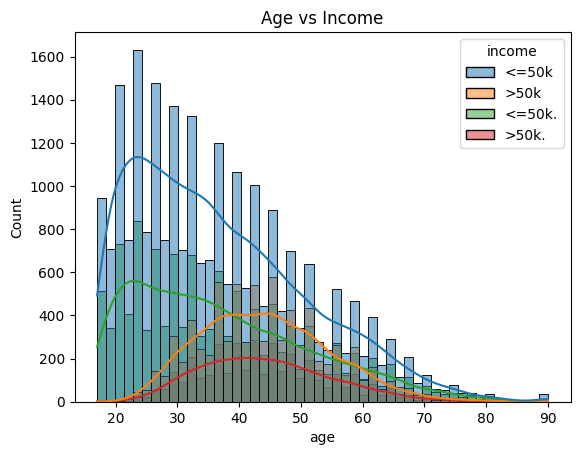

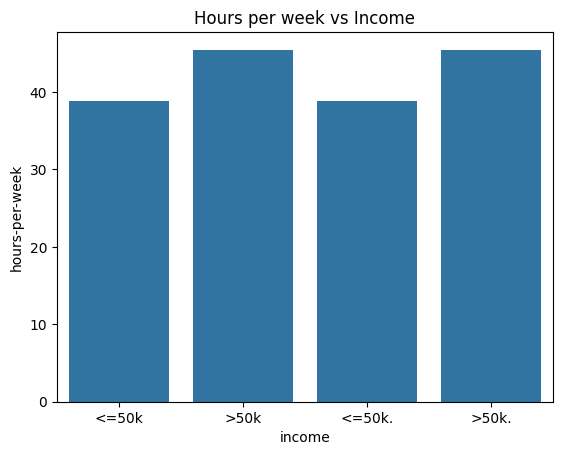

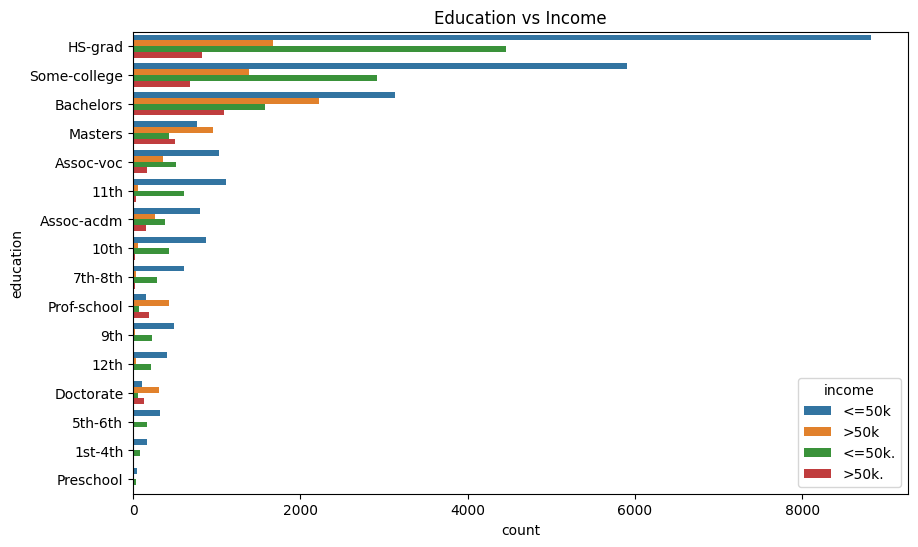

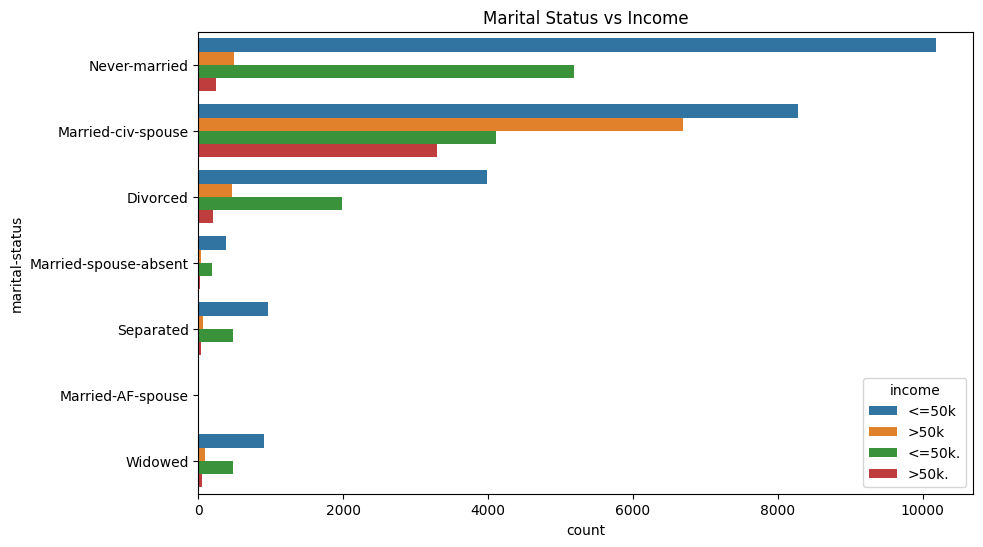

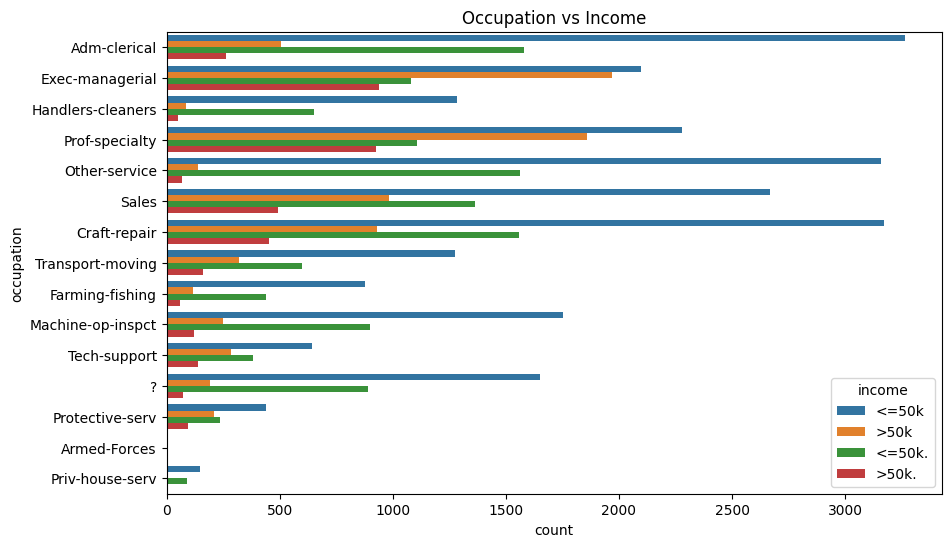


Hours Per Week Difference: 6.63281604370686
Age Difference: 7.466102717480801
Occupation Difference: occupation
Exec-managerial      0.323365
Prof-specialty       0.301199
Protective-serv      0.214649
Tech-support         0.195712
Sales                0.178597
Craft-repair         0.151996
Transport-moving     0.135881
Adm-clerical         0.090358
Machine-op-inspct    0.082727
Farming-fishing      0.077181
?                    0.067996
Armed-Forces         0.066667
Handlers-cleaners    0.041506
Other-service        0.027829
Priv-house-serv      0.004132
Name: income, dtype: float64


In [60]:
# load dataset
df = pd.read_csv('adult_income.csv')

# Perform EDA using appropriate charts and basic descriptive statistics.
print(df.info())
print()
print('Shape:', df.shape)
print()
print('First 10 rows:', df.head(10))
print()
print(df.isnull().sum())
print()
print(df.describe())

df['income'] = df['income'].astype(str).str.strip().str.lower()

age_mean = df.groupby('income')['age'].mean()
hours_mean = df.groupby('income')['hours-per-week'].mean()

print('Age Mean: \n', age_mean)
print()
print('Hours Mean: \n', hours_mean)
print()

sns.histplot(data = df, x = 'age', hue = 'income', kde = True, bins = 50).set_title('Age vs Income')
plt.show()

print()

sns.barplot(data = df, x = 'income', y = 'hours-per-week', errorbar = None).set_title('Hours per week vs Income')
plt.show()

print()

plt.figure(figsize = (10, 6))
sns.countplot(data = df, y = 'education', hue = 'income', order = df['education'].value_counts(normalize = True).index).set_title('Education vs Income')
plt.show()

print()

plt.figure(figsize = (10, 6))
sns.countplot(data = df, y = 'marital-status', hue = 'income').set_title('Marital Status vs Income')
plt.show()

print()

plt.figure(figsize = (10, 6))
sns.countplot(data = df, y = 'occupation', hue = 'income').set_title('Occupation vs Income')
plt.show()

print()

# Select your top 3 features and justify your choices using visual and statistical evidence.
high_income = df[df['income'] == '>50k']
low_income = df[df['income'] == '<=50k']

hours_diff = hours_mean['>50k'] - hours_mean['<=50k']
print('Hours Per Week Difference:', hours_diff)

# Hours-per-week difference justification: From the barplot we can see that the people who earn more than 50k than the people who earn less than 50k works more hours.
# Also from the statistical measure, we can say that the people who earn more than 50k works 6.6 hours more than the people who earn less than 50k.

age_diff = age_mean['>50k'] - age_mean['<=50k']
print('Age Difference:', age_diff)

# Age difference justification: From the histplot we can see that the people who earn more than 50k are older (age 40 - 50) than the younger people who earn less than 50k.
# Also from the statistical measure we can see that the age difference is around 7.47 which indicates that older people earns more than the younger people because they has more experience and knowledge.

total_val = df.groupby('occupation')['income'].count()
high_val = high_income.groupby('occupation')['income'].count()
occu_diff = (high_val / total_val).sort_values(ascending = False)
print('Occupation Difference:', occu_diff)

# Occupation Income justification: From the countplot we can see that the exec-managerial and pro-speciality occupations earns more that 50k than the Handlers-cleaners, Other-service and Priv-house-serv.
# Also from the statistical measure we can see the there are huge gap among these occupations and it separates these groups from each other.

# For each selected feature, explain in simple terms why it intuitively affects income.
# Age: Older people possess more work experience and problem solving skills than the younger people which directly affects the income.
# Hours per week: It has direct connection with the income because the people who works more hours than the regular people has more signifant impact on the company's working stream.
# Occupation: Occupation has a significant impact on income because the higher the occupation is, the more important the skills required and the more important are the responsibilities.

# Rank your 3 features from most important to least important, provide why you think that ?
# 1. Occupation: It has the most significance because the people with the managerial and professional roles has more complicated and important responsibilies than the other occupations.
# naturally it would have more income and it clearly shows the gap of earnings among other occupations.

# 2. Age: The older people possess immense experience and skills which the younger people lacks. Because of these reasons even the younger people work more hours they would get the lower earnings
# than the older people who has more efficient ways to get the jobs done in short times.

# 3. Hours per week: The people who works more hours in a week naturally would earn more than the regular people who works scheduled hours. Even if they are young, the consequence falls on
# the efforts the employees are giving for their jobs.

# Question 2: Preprocessing Pipeline Design (Regression) - 20
Problem Statement:
Predicting a continuous variable requires clean, properly formatted data. You will design a preprocessing pipeline to prepare the dataset for predicting hours-per-week based on the other available features.

Tasks:
- Design Scikit-Learn Pipelines that handles missing values, categorical feature encoding, and numerical feature scaling.
- Documentation: Clearly explain what specific preprocessing steps you applied to which columns and why you chose those specific methods.


In [71]:
X = df.drop('hours-per-week', axis = 1)
y = df['hours-per-week']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Design Scikit-Learn Pipelines that handles missing values, categorical feature encoding, and numerical feature scaling.
num_cols = X_train.select_dtypes(include = 'int64').columns
cat_cols = X_train.select_dtypes(include = 'object').columns

num_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(missing_values=np.nan, fill_value='missing', strategy = 'constant')),
        ('encoder', OneHotEncoder(sparse_output = False, handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

preprocessor

# Documentation: Clearly explain what specific preprocessing steps you applied to which columns and why you chose those specific methods.

# For numeric cols: I applied simpleimputer and used strategy median to impute the missing values. I could use mean but it would be highly affected to the outliers.
# Also i used standardscaler as the scaling method because it would bring all the outliers which might be useful onto a measurable scale.

# For categorical cols: I applied simpleimputer and Used strategy: constant with fill_value : missing so that missing categorical values are explicitly labeled rather than imputed with a real category, which could be biased.
# Also i used onehotencoder as the encoder because it converts the categorical data into calculable data for the machines and i handles the unwanted unknown data with handle_unkown.

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])

# Question 3: Regression Modeling & Evaluation - 20
Problem Statement:
Utilizing the preprocessing pipeline designed in Question 2, train two different regression models to predict hours-per-week and evaluate their performance.

Tasks:
- Train a standard Linear Regression model using your pipeline.
- Train a Stochastic Gradient Descent (SGD) Regressor model using your pipeline.
- Evaluate and compare both models using R2, MAE, and MSE.
- Briefly discuss which model performed better and why.


In [78]:
# Train a standard Linear Regression model using your pipeline.
lr_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)
lr_pipeline.fit(X_train, y_train)

# Train a Stochastic Gradient Descent (SGD) Regressor model using your pipeline.
sgd_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', SGDRegressor(
            random_state = 42,
            eta0 = 0.001,
            alpha = 0.0001,
            loss = 'squared_error',
            penalty = 'l2',
            learning_rate = 'constant',
            max_iter = 1000
        ))
    ]
)
sgd_pipeline.fit(X_train, y_train)

# Evaluate and compare both models using R2, MAE, and MSE.
def evaluate(model, name):
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  train_r2 = r2_score(y_train, train_pred)
  test_r2 = r2_score(y_test, test_pred)
  train_mae = mean_absolute_error(y_train, train_pred)
  test_mae = mean_absolute_error(y_test, test_pred)
  train_mse = mean_squared_error(y_train, train_pred)
  test_mse = mean_squared_error(y_test, test_pred)

  return {
      'Model'      : name,
      'Train MSE'  : round(train_mse, 2),
      'Test MSE'   : round(test_mse, 2),
      'Train MAE'  : round(train_mae, 2),
      'Test MAE'   : round(test_mae, 2),
      'Train R2'   : round(train_r2, 4),
      'Test R2'    : round(test_r2, 4)
  }

lr_results = evaluate(lr_pipeline, 'Linear Regression')
sgd_results = evaluate(sgd_pipeline, 'SGD Regressor')

results = pd.DataFrame([lr_results, sgd_results])
results = results.set_index('Model')
print(results)

# Briefly discuss which model performed better and why.

# From the observation it can be said that the Linear Regression performed better that scohatic regression in 3 metrics.
# Linear regressor provides higher test r2 rate 0.20 than sgd regressor 0.19 which indicates that it explains more variances in hour per week.
# Linear regressor has less test MAE 7.66 than sgd regressor 7.67 which indicates that it is closer to the actual values than sgd regressor.
# Linear regressor has less test MSE 122.44 than sgd regressor 122.78 which means it has fewer prediction errors than sgd regressor.

                   Train MSE  Test MSE  Train MAE  Test MAE  Train R2  Test R2
Model                                                                         
Linear Regression     123.02    122.44       7.70      7.66    0.1991   0.2014
SGD Regressor         123.62    122.78       7.71      7.67    0.1952   0.1992
